## Infos
- Remove Night timestamps, due to DR-Flags = 0

Install all necessary libraries.

In [1]:
%pip install torch
%pip install pandas
%pip install numpy
%pip install scikit-learn
%pip install matplotlib
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu129

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cu129
Note: you may need to restart the kernel to use updated packages.


Import all necessary libraries.

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

Set seed for reproducibility.

In [3]:
torch.manual_seed(42)
np.random.seed(42)

In [4]:
df_train = pd.read_csv("../data/regression/regression-train.csv")
df_test = pd.read_csv("../data/regression/regression-test.csv")

In [5]:
print(f"Dataset shape: {df_train.shape}")
print(f"\nColumns: {df_train.columns.tolist()}")

Dataset shape: (105120, 7)

Columns: ['Site', 'Timestamp_Local', 'Dry_Bulb_Temperature_C', 'Global_Horizontal_Radiation_W/m2', 'Building_Power_kW', 'Demand_Response_Flag', 'Demand_Response_Capacity_kW']


In [6]:
df_train.head()

,Site,Timestamp_Local,Dry_Bulb_Temperature_C,Global_Horizontal_Radiation_W/m2,Building_Power_kW,Demand_Response_Flag,Demand_Response_Capacity_kW
0,siteA,2019-01-01 00:00:00,22.20,0.0,4.8,0,0.0
1,siteA,2019-01-01 00:15:00,22.27,0.0,4.8,0,0.0
2,siteA,2019-01-01 00:30:00,22.35,0.0,4.8,0,0.0
3,siteA,2019-01-01 00:45:00,22.42,0.0,4.8,0,0.0
4,siteA,2019-01-01 01:00:00,22.50,0.0,4.8,0,0.0


In [7]:
def add_time_features(df):
    df['Timestamp_Local'] = pd.to_datetime(df['Timestamp_Local'])
    df['hour'] = df['Timestamp_Local'].dt.hour
    df['minute'] = df['Timestamp_Local'].dt.minute
    df['day_of_month'] = df['Timestamp_Local'].dt.day
    df['day'] = df['Timestamp_Local'].dt.day  # Same as day_of_month
    df['month'] = df['Timestamp_Local'].dt.month
    df['day_of_week'] = df['Timestamp_Local'].dt.dayofweek
    return df

In [8]:
df_train = add_time_features(df_train)

Encode categorical feature (Site) -> neural networks can only process numerical data, not categorical text labels.

In [9]:
le = LabelEncoder()
df_train['Site_Encoded'] = le.fit_transform(df_train['Site'])

Select features -> to clearly separate inputs (X) from output (y) for machine learning.

It's important to only prepare features for scaling which need to be scaled (continuous). The categorical features get concatinated again after scaling the continuous features. 

For now the time features are also defined as a categorical feature, but it makes more sense to use **cyclical encoding**. The reason for this is that for example 11PM and midnight are numerically very far apart (23 and 0), even tho they are actually close to each other.

Example:
- df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
- df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

- df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
- df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

- df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
- df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

In [10]:
continuous_feature_columns = ['Dry_Bulb_Temperature_C', 
                   'Global_Horizontal_Radiation_W/m2', 'Building_Power_kW']
categorical_feature_columns = ['Site_Encoded', 'Demand_Response_Flag', 'hour', 'minute', 'day_of_month', 
                   'day', 'month', 'day_of_week']

target_column = 'Demand_Response_Capacity_kW'

In [11]:
print(continuous_feature_columns)
print(target_column)

['Dry_Bulb_Temperature_C', 'Global_Horizontal_Radiation_W/m2', 'Building_Power_kW']
Demand_Response_Capacity_kW


Convert to numpy array and reshape the target variable
- **Why convert?**: NumPy arrays are faster and more memory-efficient for numerical computations.
- **Why reshape?**: Reshape to make feature and target variable the same size to make them comparable (from 1D to 2D).

In [12]:
X_continuous = df_train[continuous_feature_columns].values # Convert to numpy array
X_categorical = df_train[categorical_feature_columns].values # Convert to numpy array
y = df_train[target_column].values.reshape(-1, 1) # Convert to numpy array and reshape

In [13]:
print(f"Continuous feature shape: {X_continuous.shape}")
print(f"Categorical feature shape: {X_categorical.shape}")
print(f"Target shape: {y.shape}")

Continuous feature shape: (105120, 3)
Categorical feature shape: (105120, 8)
Target shape: (105120, 1)


Scale features
- **Why scaling?**: Features with larger values dominate the learning process! (Gradient Descent Gets Confused, Exploding/Vanishing Gradients, Unfair Feature Importance)
- Benefits: All features have equal influence initially, Gradients are stable and balanced, Optimizer converges much faster, Model learns actual patterns (not just scales)

In [14]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X_continuous)
y = scaler_y.fit_transform(y)

Concatenate the unscaled and the scaled features together.

In [15]:
X = np.concatenate([X_scaled, X_categorical], axis=1)

In [16]:
print(f"Continuous feature shape: {X.shape}")
print(X[0])

Continuous feature shape: (105120, 11)
[ 0.83262963 -0.75734429 -0.51225014  0.          0.          0.
  0.          1.          1.          1.          1.        ]


Split data -> Split the data into training and validation.

In [17]:
# Assuming: Site_A → 0, Site_B → 1, Site_C → 2
train_mask = np.isin(X[:, 3], [0, 1])  # Site_A and Site_B
val_mask = X[:, 3] == 2                # Site_C

X_train = X[train_mask]
X_val = X[val_mask]
y_train = y[train_mask]
y_val = y[val_mask]

In [18]:
print(len(X_train))
print(len(y_train))
print(len(X_val))
print(len(y_val))

70080
70080
35040
35040


Create sequences to create a "sliding window" for the RNN architechture to predict the current hidden state based on the past values.

In [19]:
def create_sequences(X, y, seq_length=10):
    sequences_X = []
    sequences_y = []
    
    for i in range(len(X) - seq_length):
        sequences_X.append(X[i:i+seq_length])
        sequences_y.append(y[i+seq_length])
    
    return np.array(sequences_X), np.array(sequences_y)

In [20]:
X_train_seq, y_train_seq = create_sequences(X_train, y_train)
X_val_seq, y_val_seq = create_sequences(X_val, y_val)

In [21]:
print(f"Training sequences shape: {X_train_seq.shape}, Training targets shape: {y_train_seq.shape}")
print(f"Validation sequences shape: {X_val_seq.shape}, Validation targets shape: {y_val_seq.shape}")

Training sequences shape: (70070, 10, 11), Training targets shape: (70070, 1)
Validation sequences shape: (35030, 10, 11), Validation targets shape: (35030, 1)


Create "class PowerDataset" for converting numpy arrays to PyTorch tensors (required for PyTorch models).
- __len__: Tells PyTorch how many samples are in the dataset
- __getitem__: Allows indexing

In [22]:
class PowerDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X) # Convert numpy → PyTorch tensor
        self.y = torch.FloatTensor(y) # Convert numpy → PyTorch tensor
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

Create DataLoader -> DataLoader's job: Efficiently load data in batches during training

In [23]:
train_dataset = PowerDataset(X_train_seq, y_train_seq)
val_dataset = PowerDataset(X_val_seq, y_val_seq)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) # Shuffle training data to reduce bias throughout the year
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

Create a simple RNN architecture.

Why not use nn.RNN: nn.RNN is just the recurrent layer - it's not a complete model. You need additional components to make predictions.

In [24]:
class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(SimpleRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, 
                          batch_first=True, nonlinearity='relu')
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        out, _ = self.rnn(x, h0)
        # Take the last time step
        out = out[:, -1, :]
        out = self.fc(out)
        return out

Define hyperparameters for the model.

In [25]:
input_size = X_train_seq.shape[2]
hidden_size = 64
num_layers = 2
output_size = 1

Define cuda as the device to make the training possible to the GPU.

In [26]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


Generate model.

In [27]:
model = SimpleRNN(input_size, hidden_size, num_layers, output_size).to(device)
print(f"Model architecture:\n{model}")

Model architecture:
SimpleRNN(
  (rnn): RNN(11, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


Setup the loss function and optimizer.

In [28]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Training.

In [29]:
num_epochs = 10
train_losses = []
val_losses = []

print("Starting training...")
for epoch in range(num_epochs):
    # Training
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        # Forward pass
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
    
    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

print("Training completed!")

Starting training...
Epoch [10/10], Train Loss: 0.0078, Val Loss: 2.7029
Training completed!


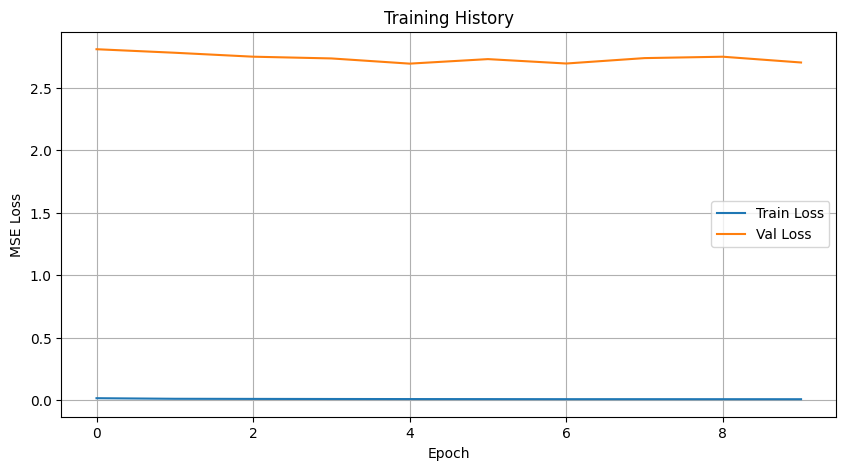

In [30]:
# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training History')
plt.legend()
plt.grid(True)


Validation Metrics:
RMSE: 7.2832 kW
MAE: 1.1336 kW
R2 Score: 0.0862


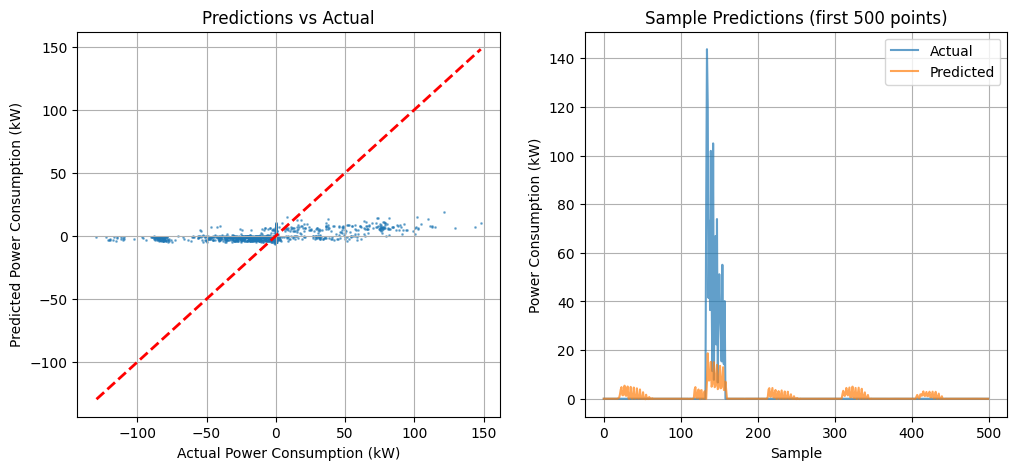

In [31]:
# Make predictions on validation set
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        all_preds.append(outputs.cpu().numpy())
        all_targets.append(y_batch.numpy())

all_preds = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

# Inverse transform predictions
preds_original = scaler_y.inverse_transform(all_preds)
targets_original = scaler_y.inverse_transform(all_targets)

# Calculate metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(targets_original, preds_original)
rmse = np.sqrt(mse)
mae = mean_absolute_error(targets_original, preds_original)
r2 = r2_score(targets_original, preds_original)

print(f"\nValidation Metrics:")
print(f"RMSE: {rmse:.4f} kW")
print(f"MAE: {mae:.4f} kW")
print(f"R2 Score: {r2:.4f}")

# Plot predictions vs actual
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(targets_original, preds_original, alpha=0.5, s=1)
plt.plot([targets_original.min(), targets_original.max()], 
         [targets_original.min(), targets_original.max()], 'r--', lw=2)
plt.xlabel('Actual Power Consumption (kW)')
plt.ylabel('Predicted Power Consumption (kW)')
plt.title('Predictions vs Actual')
plt.grid(True)

plt.subplot(1, 2, 2)
sample_size = min(500, len(targets_original))
plt.plot(targets_original[:sample_size], label='Actual', alpha=0.7)
plt.plot(preds_original[:sample_size], label='Predicted', alpha=0.7)
plt.xlabel('Sample')
plt.ylabel('Power Consumption (kW)')
plt.title(f'Sample Predictions (first {sample_size} points)')
plt.legend()
plt.grid(True)